## 1: Loading XA+NA TV reconstruction and correcting for phase artifacts at edge
(XA: Xray, slice A, NA: Neutron slice A, DA: Diffraction slice A)

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import os
os.chdir('/zhome/71/c/146676/main/')
from helpers import module_auxiliary as ma
from loaders import stitcher_XA
from loaders import loader_XA_to_NA
import SimpleITK as sitk
import copy

#### You can change the reconstruction type in the code block below. dataset_XA can be 'fbp' or 'tv'. dataset_NA can be 'tv', 'dtv' or 'fbp'.

In [2]:
xray_slices = range(0,2800) # Which xray slices to load? Starting from around 0 to around 3200
neutron_slices = range(0,1650) # Which neutron slices to load? Starting from 0 to around 1700. Slice 0 are at different ends of the meteorite
output_volume = [[0,1650],[None], [None]] # The slices included in the arrays that the registerred volumes are saved to (just set first coordinate 
# equal the numbers in Neutron slices, and the others to None (indicating to include all the data))


# Now read the datafrom disc, and register XA to NA. h=1 indicates that the neutron resolution should be used. Setting h higher, you can take advantage
# of the higher resolution of the xray data, but this requires changing output_volume
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset_XA='tv', dataset_NA='tv' , h=1, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Loading xray data
Loading neutron data
Resampling the transformation
Resampling moving image


#### Convert to np arrays

In [3]:
XA = sitk.GetArrayFromImage(reg.moving)
NA = sitk.GetArrayFromImage(reg.fixed)

#### Create a function that can segment the volume into rock/air

In [4]:
def segment_rock(input_image, threshold = 0.01):
    # Downsample by factor of 3
    # Compute new size and spacing
    factor = 3
    new_size = [int(s / factor) for s in input_image.GetSize()]
    new_spacing = [s * factor for s in input_image.GetSpacing()]

    # Resample the image (downsampling)
    resample = sitk.ResampleImageFilter()
    resample.SetSize(new_size)
    resample.SetOutputSpacing(new_spacing)
    resample.SetInterpolator(sitk.sitkLinear)
    resample.SetOutputOrigin(input_image.GetOrigin())  # Copy origin
    resample.SetOutputDirection(input_image.GetDirection())  # Copy direction
    downsampled_image = resample.Execute(input_image)


    # Apply Gaussian smoothing
    smoothed_image = sitk.SmoothingRecursiveGaussian(downsampled_image, sigma=0.01)

    # Threshold-based segmentation (choose a threshold manually)
    lower_threshold = threshold  # Change this value based on your data
    upper_threshold = 255
    binary_image = sitk.BinaryThreshold(smoothed_image, lowerThreshold=lower_threshold, upperThreshold=upper_threshold, insideValue=1, outsideValue=0)

    # **Keep only the largest connected component of class 1 (object)**
    cc_object = sitk.ConnectedComponent(binary_image)  # Label connected regions
    object_sizes = sitk.LabelShapeStatisticsImageFilter()
    object_sizes.Execute(cc_object)
    largest_label = max(object_sizes.GetLabels(), key=lambda l: object_sizes.GetPhysicalSize(l))
    largest_object = sitk.BinaryThreshold(cc_object, lowerThreshold=largest_label, upperThreshold=largest_label, insideValue=1, outsideValue=0)

    # **Keep only the largest connected component of class 0 (background)**
    inverted_binary = sitk.BinaryNot(largest_object)  # Invert image
    cc_background = sitk.ConnectedComponent(inverted_binary)
    background_sizes = sitk.LabelShapeStatisticsImageFilter()
    background_sizes.Execute(cc_background)
    largest_label_bg = max(background_sizes.GetLabels(), key=lambda l: background_sizes.GetPhysicalSize(l))
    largest_background = sitk.BinaryThreshold(cc_background, lowerThreshold=largest_label_bg, upperThreshold=largest_label_bg, insideValue=1, outsideValue=0)

    # Invert background back to 0
    final_segmented = sitk.BinaryNot(largest_background)

    # Resample back to original resolution (upsampling)
    resample.SetSize(input_image.GetSize())
    resample.SetOutputSpacing(input_image.GetSpacing())
    resample.SetInterpolator(sitk.sitkNearestNeighbor)  
    resample.SetOutputOrigin(input_image.GetOrigin())  
    resample.SetOutputDirection(input_image.GetDirection())  
    final_segmented = resample.Execute(final_segmented)
    return final_segmented

#### Get NP arrays of the segmentations

In [5]:
XA_e = sitk.GetArrayFromImage(segment_rock(reg.moving, threshold = 0.010)).astype(bool).astype(np.int8)
NA_e = sitk.GetArrayFromImage(segment_rock(reg.fixed, threshold = 0.015)).astype(bool).astype(np.int8)

In [29]:
print(np.shape(NA_e))
saver_ = XA*XA_e
q = np.quantile(saver_, 0.99)
saver = np.clip(saver_, a_min=0, a_max=q)
saver = saver/q*255
new = saver.astype(np.uint8)

np.save('/dtu-compute/msaca/visualizations/model_XA_3d.npy',new)

(1650, 360, 1600)


In [31]:
np.save('/dtu-compute/msaca/visualizations/model_XA_3d_verylowres.npy',new[::4,::4,::4])

In [ ]:
print(q)
print(np.median(new))
plt.imshow(new[:,100])
plt.clim([0,255])

#### Extract upper and lower outer edges of both XA and NA recons

In [6]:
NA_d = np.diff(NA_e,axis=1)
edge_index_NA_lower = np.argmax(NA_d[:,40:-40], axis=1)+40
edge_index_NA_lower[np.all(NA_d == False, axis=1)] = -1
edge_index_NA_lower = np.clip(edge_index_NA_lower*NA_e[:,90],a_min=10,a_max=350)

NA_d = np.diff(NA_e,axis=1)
rev_first_true_idx = np.argmax(NA_e[:, -40:40:-1, :], axis=1)+40
edge_index_NA_upper= NA_e.shape[1] - 1 - rev_first_true_idx
edge_index_NA_upper[np.all(NA_e == False, axis=1)] = -1
edge_index_NA_upper = np.clip(edge_index_NA_upper,a_min=10,a_max=350)

XA_d = np.diff(XA_e,axis=1)
edge_index_XA_lower = np.argmax(XA_d[:,40:-40], axis=1)+40
edge_index_XA_lower[np.all(XA_d == False, axis=1)] = -1
edge_index_XA_lower = np.clip(edge_index_XA_lower*XA_e[:,90],a_min=10,a_max=350)

NA_d = np.diff(NA_e,axis=1)
rev_first_true_idx = np.argmax(XA_e[:, -40:40:-1, :], axis=1)+40
edge_index_XA_upper= XA_e.shape[1] - 1 - rev_first_true_idx
edge_index_XA_upper[np.all(XA_e == False, axis=1)] = -1
edge_index_XA_upper = np.clip(edge_index_XA_upper,a_min=10,a_max=350)


#### Display a plot of the indices of the outer edge: Does it look plausible? Test XA_upper, XA_lower, NA_upper, NA_lower

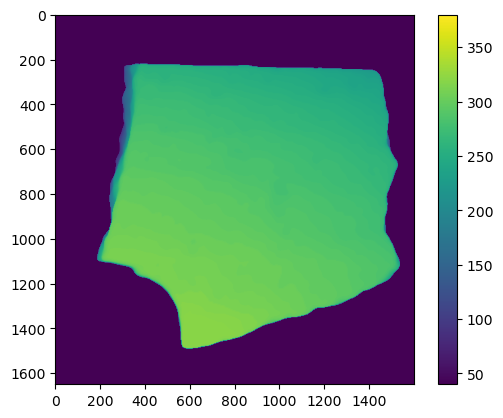

In [7]:
plt.imshow(edge_index_XA_upper)
plt.colorbar()
plt.clim([40,380])

#### Do mean normalization a distance "i" from each edge

"i" goes from 0 to 50 pixels into the image

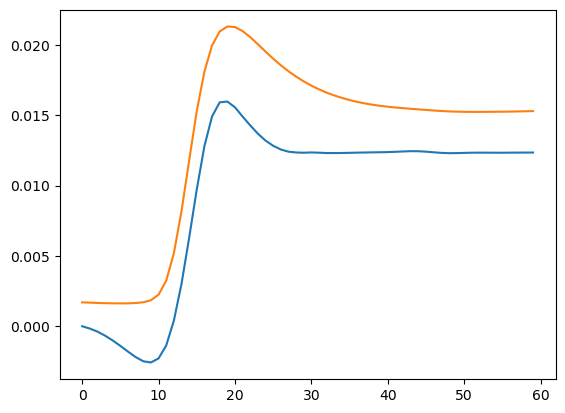

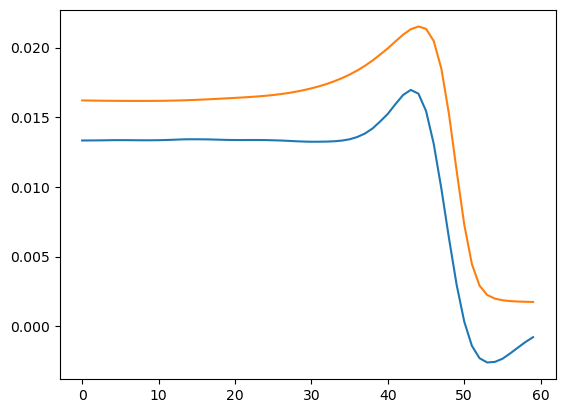

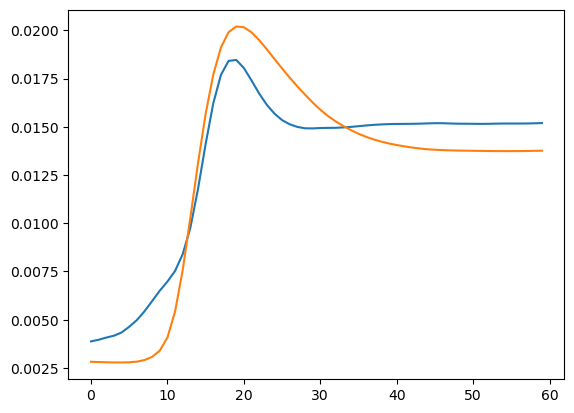

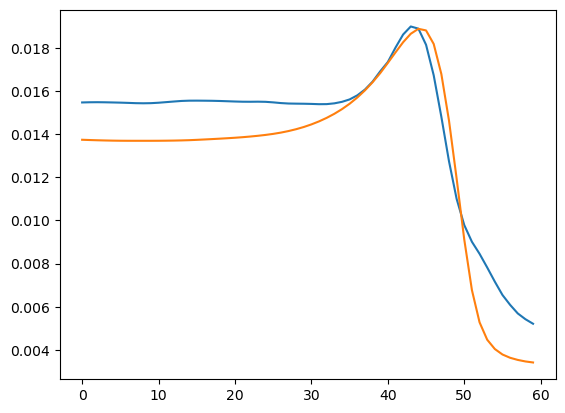

In [8]:
XA_corrected = copy.deepcopy(XA)
NA_corrected = copy.deepcopy(NA)
nz, ny, nx = np.shape(NA)

phase_artifact_range = np.arange(-10,50)
phase_means_NA_lower = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_lower = np.zeros(np.shape(phase_artifact_range))
phase_sd_NA_lower = np.zeros(np.shape(phase_artifact_range))
phase_sd_XA_lower = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_lower[i] = np.mean(edge_layer_NA)
    phase_sd_NA_lower[i] = np.std(edge_layer_NA)
    edge_layer_XA = XA[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_lower[i] = np.mean(edge_layer_XA)
    phase_sd_XA_lower[i] = np.std(edge_layer_XA)

background_mean_NA_lower = np.mean(phase_means_NA_lower[-10:])
background_mean_XA_lower = np.mean(phase_means_XA_lower[-10:])
background_sd_NA_lower = np.mean(phase_sd_NA_lower[-10:])
background_sd_XA_lower = np.mean(phase_sd_XA_lower[-10:])


for i in range(9,60):
    NA_corrected[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)] =\
        (NA[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)] -\
        phase_means_NA_lower[i])*background_sd_NA_lower/phase_sd_NA_lower[i]+ background_mean_NA_lower
    
    XA_corrected[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)] =\
        (XA[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)] -\
         phase_means_XA_lower[i])*background_sd_XA_lower/phase_sd_XA_lower[i]+ background_mean_XA_lower



phase_artifact_range = np.arange(-50,10)
phase_means_NA_upper = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_upper = np.zeros(np.shape(phase_artifact_range))
phase_sd_NA_upper = np.zeros(np.shape(phase_artifact_range))
phase_sd_XA_upper = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_upper[i] = np.mean(edge_layer_NA)
    phase_sd_NA_upper[i] = np.std(edge_layer_NA)
    edge_layer_XA = XA[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_upper[i] = np.mean(edge_layer_XA)
    phase_sd_XA_upper[i] = np.std(edge_layer_XA)

background_mean_NA_upper = np.mean(phase_means_NA_upper[:10])
background_mean_XA_upper = np.mean(phase_means_XA_upper[:10])
background_sd_NA_upper = np.mean(phase_sd_NA_upper[:10])
background_sd_XA_upper = np.mean(phase_sd_XA_upper[:10])

for i in range(0,51):
    NA_corrected[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)] =\
        (NA[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)] -\
        phase_means_NA_upper[i])*background_sd_NA_upper/phase_sd_NA_upper[i]+ background_mean_NA_upper
    
    XA_corrected[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)] =\
        (XA[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)] -\
         phase_means_XA_upper[i])*background_sd_XA_upper/phase_sd_XA_upper[i]+ background_mean_XA_upper


plt.plot(phase_means_XA_lower)
plt.plot(phase_means_NA_lower)
plt.show()

plt.plot(phase_means_XA_upper)
plt.plot(phase_means_NA_upper)
plt.show()

plt.plot(phase_sd_XA_lower)
plt.plot(phase_sd_NA_lower)
plt.show()

plt.plot(phase_sd_XA_upper)
plt.plot(phase_sd_NA_upper)
plt.show()

0.015456248181482963
0.015456248181482935
0.01545624818148295
0.015456248181482946
0.015456248181482946
0.015456248181482944
0.015456248181482963
0.015456248181482966
0.015456248181482966
0.015456248181482946
0.015456248181482942
0.015456248181482946
0.015456248181482952
0.015456248181482947
0.015456248181482947
0.015456248181482932
0.015456248181482947
0.01545624818148297
0.015456248181482946
0.015456248181482949
0.015456248181482932
0.015456248181482942
0.01545624818148294
0.015456248181482965
0.015456248181482956
0.01545624818148293
0.015456248181482977
0.015456248181482952
0.015456248181482926
0.015456248181482963
0.01545624818148295
0.015456248181482961
0.015456248181482947
0.015456248181482939
0.015456248181482946
0.015456248181482944
0.015456248181482949
0.015456248181482946
0.015456248181482956
0.01545624818148297
0.015456248181482932
0.01545624818148296
0.015456248181482932
0.015456248181482952
0.015456248181482949
0.01545624818148297
0.015456248181482946
0.015456248181482956


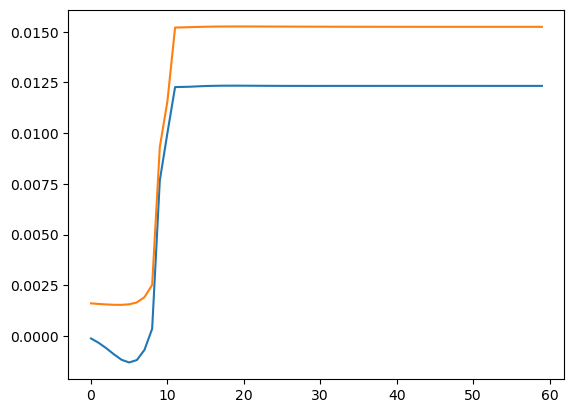

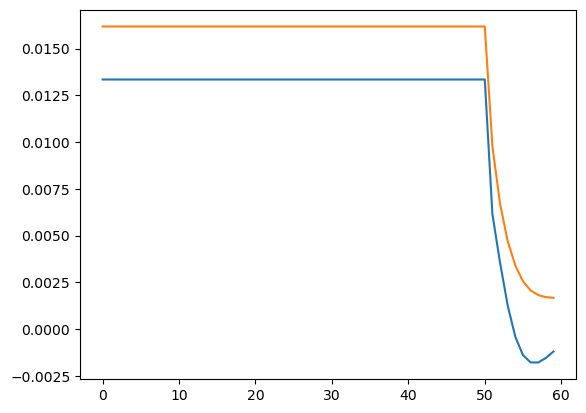

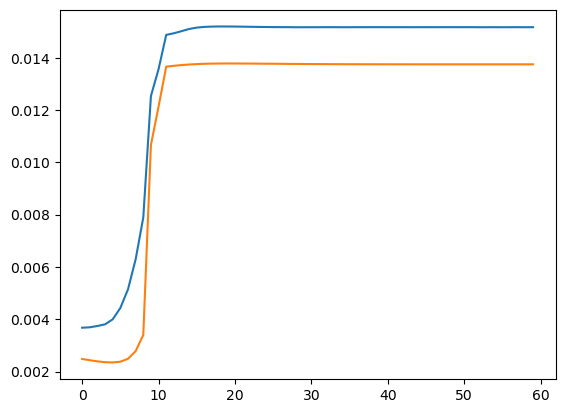

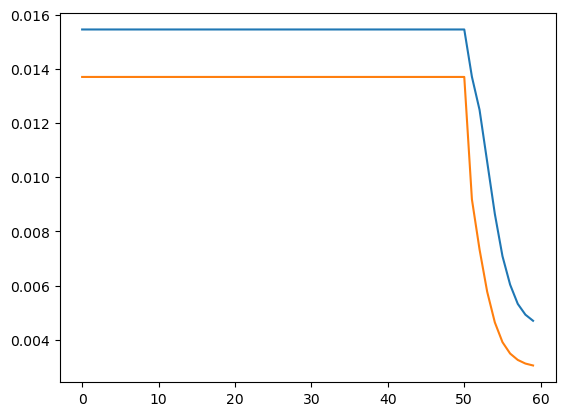

In [9]:
phase_artifact_range = np.arange(-10,50)
phase_means_NA_lower = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_lower = np.zeros(np.shape(phase_artifact_range))
phase_sd_NA_lower = np.zeros(np.shape(phase_artifact_range))
phase_sd_XA_lower = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA_corrected[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_lower[i] = np.mean(edge_layer_NA)
    phase_sd_NA_lower[i] = np.std(edge_layer_NA)
    edge_layer_XA = XA_corrected[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_lower[i] = np.mean(edge_layer_XA)
    phase_sd_XA_lower[i] = np.std(edge_layer_XA)


phase_artifact_range = np.arange(-50,10)
phase_means_NA_upper = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_upper = np.zeros(np.shape(phase_artifact_range))
phase_sd_NA_upper = np.zeros(np.shape(phase_artifact_range))
phase_sd_XA_upper = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA_corrected[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_upper[i] = np.mean(edge_layer_NA)
    phase_sd_NA_upper[i] = np.std(edge_layer_NA)
    edge_layer_XA = XA_corrected[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_upper[i] = np.mean(edge_layer_XA)
    print(np.std(edge_layer_XA))
    phase_sd_XA_upper[i] = np.std(edge_layer_XA)


plt.plot(phase_means_XA_lower)
plt.plot(phase_means_NA_lower)
plt.show()

plt.plot(phase_means_XA_upper)
plt.plot(phase_means_NA_upper)
plt.show()

plt.plot(phase_sd_XA_lower)
plt.plot(phase_sd_NA_lower)
plt.show()

plt.plot(phase_sd_XA_upper)
plt.plot(phase_sd_NA_upper)
plt.show()


#### Let's see the effect of the change:

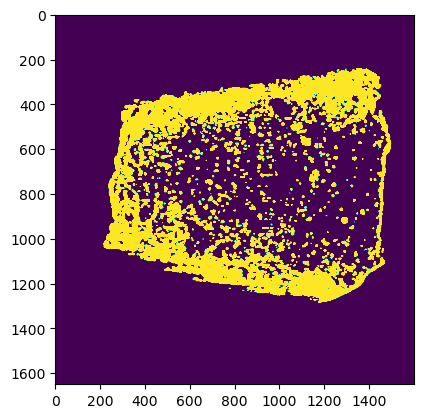

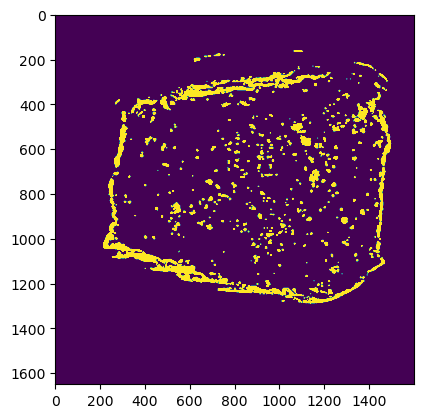

In [10]:
plt.close('all')
plt.imshow(NA[:,80]>0.035)
plt.clim([0,0.05])
plt.show()
plt.imshow(NA_corrected[:,80]>0.035)
plt.clim([0,0.05])
plt.show()

#### This should reduce the thickness of the edge

#### You can now do analysis on XA_corrected and NA_corrected!

Some options: Save them to disc, or copy paste the stuff above into a script, and run this script before doing the analyis. The bottleneck is to read the volumes from disc to RAM in both cases

## Register to DA

#### Load the specific part of the volumes that match with diffraction data

In [11]:
XA_d = XA[600-output_volume[0][0]:1000-output_volume[0][0]]
NA_d = NA_corrected[600-output_volume[0][0]:1000-output_volume[0][0]]

#### Load the diffraction data

In [13]:
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset = f["absorption"]
    DA = dataset[:,120:240]

Keys: ['absorption']


#### Register XA with DA (and do NA later). Step 1: Cast to SITK images

Naming convention: If a variable (say "arr") exists as a numpy array AND a sitk array, the sitk version will be names "arr_"

In [42]:
_ , nx_XA = np.shape(XA_d[0])
_ , nx_NA = np.shape(NA_d[0])
_ , nx_DA_2 = np.shape(DA[0])

DA_ = sitk.GetImageFromArray(DA)
XA_ = sitk.GetImageFromArray(XA_d)
NA_ = sitk.GetImageFromArray(NA_d)
DA_.SetSpacing((1/nx_DA_2,1/nx_DA_2,1/nx_DA_2))
XA_.SetSpacing((1/nx_XA,1/nx_XA,1/nx_XA))
NA_.SetSpacing((1/nx_NA,1/nx_NA,1/nx_NA))

size_fixed = DA_.GetSize()
size_moving = XA_.GetSize()


spacing_fixed = DA_.GetSpacing()
spacing_moving = XA_.GetSpacing()

# Compute the new origin (shift it to -N/2)
new_origin_fixed = [-0.5 * (size_fixed[i] - 1) * spacing_fixed[i] for i in range(len(size_fixed))]
new_origin_moving = [-0.5 * (size_moving[i] - 1) * spacing_moving[i] for i in range(len(size_moving))]

DA_.SetOrigin(new_origin_fixed)
XA_.SetOrigin(new_origin_moving)
NA_.SetOrigin(new_origin_moving)

#### Define the registration optimizer and resampler

Running the registration part is not needed for running the rest of the script, but you can play around with it if you wanna obtain an even better registration

In [43]:
def registrator(fixed, moving, thresholds = [0.0045, 0.025], sampling_percentage = 0.1, max_iter = 1000, learning_rate = 1):

    fixed_d = sitk.BinaryThreshold(fixed, lowerThreshold=thresholds[0], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    moving_d = sitk.BinaryThreshold(moving, lowerThreshold=thresholds[1], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    fixed_d =sitk.Cast(fixed_d, sitk.sitkFloat32)
    moving_d =sitk.Cast(moving_d, sitk.sitkFloat32)

    initial_transform = sitk.Similarity3DTransform()
    initial_transform.SetMatrix([1.0, 0.0, 0.0,
                                0.0, 1.0, 0.0,
                                0.0, 0.0, 1.0])

    # Set the translation to zero
    initial_transform.SetTranslation([0.0, 0.0, 0.0])
    initial_transform.SetScale(1.0)

    registration = sitk.ImageRegistrationMethod()
    registration.SetInitialTransform(initial_transform)
    registration.SetMetricAsMeanSquares()
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(sampling_percentage)

    registration.SetOptimizerAsGradientDescent(
        learningRate=learning_rate,
        numberOfIterations=max_iter,
        convergenceMinimumValue=-1e-16,
        convergenceWindowSize=1000
        )

    registration.SetInterpolator(sitk.sitkLinear)
    registration.Execute(fixed_d, moving_d)
    transform = registration.GetInitialTransform()
    return transform

def resampler(fixed, moving, transform):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)  # Reference image (fixed)
    resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
    resampler.SetTransform(transform)    # Apply the initial transform (aligned centroids)
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputSpacing(fixed.GetSpacing())  # Ensure the spacing is preserved
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())
    moving = resampler.Execute(moving)
    return moving

#### Run the registration loop

In [47]:
transform1 = registrator(DA_, XA_, thresholds = [0.0045, 0.025], sampling_percentage = .1, max_iter = 10, learning_rate = 0.3)
XA_temp = resampler(DA_, XA_, transform1)

transform2 = registrator(DA_, XA_temp, thresholds = [0.0045, 0.025], sampling_percentage = .1, max_iter = 5, learning_rate = 0.2)
XA_temp = resampler(DA_, XA_temp, transform2)


transform3 = registrator(DA_, XA_temp, thresholds = [0.0045, 0.025], sampling_percentage = .1, max_iter = 5, learning_rate = 0.1)
XA_temp = resampler(DA_, XA_temp, transform3)

transform4 = registrator(DA_, XA_temp, thresholds = [0.0045, 0.025], sampling_percentage = .1, max_iter = 5, learning_rate = 0.05)
XA_temp = resampler(DA_, XA_temp, transform4)

transform5 = registrator(DA_, XA_temp, thresholds = [0.0045, 0.025], sampling_percentage = .1, max_iter = 5, learning_rate = 0.03)
XA_temp = resampler(DA_, XA_temp, transform5)

transform6 = registrator(DA_, XA_temp, thresholds = [0.0045, 0.025], sampling_percentage = .1, max_iter = 5, learning_rate = 0.01)
XA_temp = resampler(DA_, XA_temp, transform6)

composite_transform = sitk.CompositeTransform(3)

# Add transformations in order
composite_transform.AddTransform(transform1)
composite_transform.AddTransform(transform2)
composite_transform.AddTransform(transform3)
composite_transform.AddTransform(transform4)
composite_transform.AddTransform(transform5)
composite_transform.AddTransform(transform6)
#sitk.WriteTransform(composite_transform, "transformation_NA_to_DA_slice_600_to_1000.tfm")

#### Load transformation from disc (this transformation registers slices 120 to 240 of the DA volume to slice 600 to 1000 of the neutron volume. These settings are set correctly above)

In [48]:
transform = sitk.ReadTransform("transformation_NA_to_DA_slice_600_to_1000.tfm")

#### Define the resampling function, the argument h is the resolution of the NA+XA volume compared with the DA volume

In [49]:
def resampler2(fixed, moving, transform, h=1):
    high_res=moving
    low_res=fixed
    # Get the spacing and size for the high-resolution image
    high_res_spacing = high_res.GetSpacing()
    high_res_size = high_res.GetSize()
    low_res_spacing = low_res.GetSpacing()
    low_res_size = low_res.GetSize()

    # Define the scaling factor
    scaling_factor = h  # Halve the spacing, double the size

    # Create the resampling filter
    resampler = sitk.ResampleImageFilter()

    # Set the output size (double the size)
    new_size = [int(dim * scaling_factor) for dim in low_res_size]

    # Set the output spacing (half the spacing)
    new_spacing = [spacing / scaling_factor for spacing in low_res_spacing]

    # Configure the resampler
    resampler.SetReferenceImage(low_res)  # Use the high-res image as reference
    resampler.SetSize(new_size)  # Set the new size
    resampler.SetOutputSpacing(new_spacing)  # Correct way to set spacing
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetTransform(transform)  # Apply the transformation
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())

    # Perform resampling
    return resampler.Execute(high_res)


#### Get the resampled array in high resolution. h=5 gives roughly the original resolution of the neutron data. Increasing h more will not get you to the resolution of the xray data, as this resolution was lowered when the data was loaded in from disc

In [58]:
h = 5
XA_registered_ = resampler2(DA_, XA_, transform, h=h)
XA_registered = sitk.GetArrayFromImage(XA_registered_)
NA_registered_ = resampler2(DA_, NA_, transform, h=h)
NA_registered = sitk.GetArrayFromImage(NA_registered_)

#### Get the lower res version of the data

In [68]:
h = 1
XA_registered_lowres_ = resampler2(DA_, XA_, transform, h=h)
XA_registered_lowres = sitk.GetArrayFromImage(XA_registered_lowres_)
NA_registered_lowres_ = resampler2(DA_, NA_, transform, h=h)
NA_registered_lowres = sitk.GetArrayFromImage(NA_registered_lowres_)

## How to use these arrays?

The low-res and high-res data are related by

XA_registered[::h, ::h] = XA_registered_lowres.

Pixel (i,j) from the DA volume corresponds to pixel (h*i, h*j) in the highres data

#### Plot the comparison

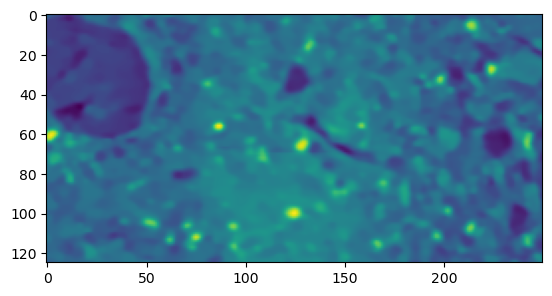

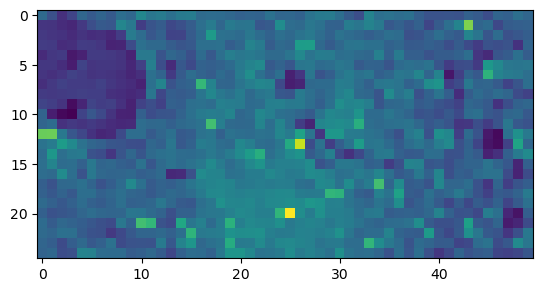

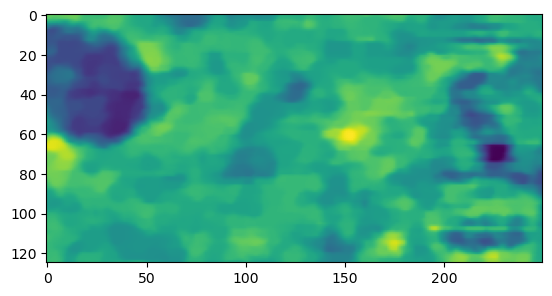

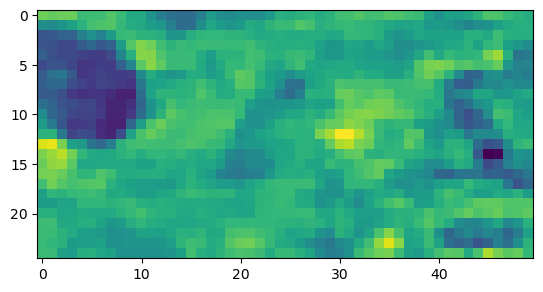

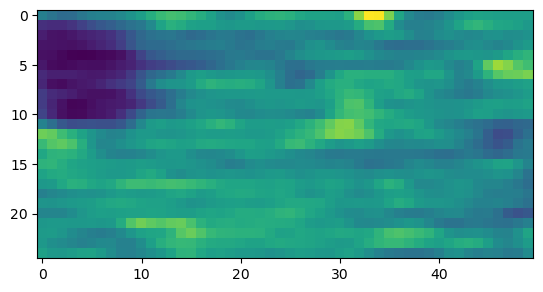

In [69]:
h = 5
box = [25,50,150,200]
slice_ = 50

plt.imshow(XA_registered[:,h*slice_][box[0]*h:box[1]*h, box[2]*h:box[3]*h])
plt.show()
plt.imshow(XA_registered_lowres[:,slice_][box[0]:box[1],box[2]:box[3]])
plt.show()
plt.imshow(NA_registered[:,h*slice_][box[0]*h:box[1]*h, box[2]*h:box[3]*h])
plt.show()
plt.imshow(NA_registered_lowres[:,slice_][box[0]:box[1],box[2]:box[3]])
plt.show()
plt.imshow(DA[:,slice_][box[0]:box[1],box[2]:box[3]])